In [2]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [3]:
stats = pd.read_csv(r'C:\PV\cleaned_data\apu_stat_10s.csv');
stats.head()

,Log Type,System,TimeStamp,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,...,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
0,APU Stat 10s,APU 1,2025-10-01 00:00:00,380.5441,382.1090,380.4408,660.0041,658.0067,661.2325,50.22484,...,0.437098,0.0,0.0,0.0,0.0,0.0,0.0,0.216413,0.165233,0.000000
1,APU Stat 10s,APU 1,2025-10-01 00:00:00,380.4019,382.1165,379.6272,659.0755,657.1038,660.3568,50.19188,...,0.402317,0.0,0.0,0.0,0.0,0.0,0.0,0.220392,0.185859,0.000049
2,APU Stat 10s,APU 1,2025-10-01 00:00:00,382.0461,380.7161,378.6526,660.3620,659.9109,663.0081,50.16247,...,0.453449,0.0,0.0,0.0,0.0,0.0,0.0,0.230665,0.220915,0.000049
3,APU Stat 10s,APU 1,2025-10-01 00:00:00,381.4481,382.7280,378.9417,660.3810,658.4229,661.7881,50.20512,...,0.452410,0.0,0.0,0.0,0.0,0.0,0.0,0.261251,0.133724,0.000099
4,APU Stat 10s,APU 1,2025-10-01 00:00:00,381.6455,381.0680,379.0313,659.5617,657.6316,660.8498,50.20505,...,0.410693,0.0,0.0,0.0,0.0,0.0,0.0,0.252505,0.202750,0.000000


In [4]:
stats.duplicated().sum()

np.int64(186)

In [5]:
stats_new = stats.drop_duplicates().reset_index(drop=True)

In [7]:
stats_apu3 = stats_new.loc[(stats_new['System'] == 'APU 3')]


In [8]:
stats_apu3.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000,240961.000000
mean,381.309854,379.896129,379.299543,660.352360,659.581000,658.647780,50.110080,176.296209,175.813322,173.901396,63.010546,63.010546,63.010546,-4.123442,-4.123442,-4.123442,589.139881,164.893237,191.613337
std,6.382863,6.354653,6.374887,10.757056,10.716681,10.499706,0.100774,272.010421,270.551973,268.131027,100.236427,100.236427,100.236427,15.723765,15.723765,15.723765,579.923490,266.224225,305.972451
min,352.393700,351.414600,350.398500,600.243500,580.998700,578.400400,49.611720,0.281377,0.351371,0.358429,-26.940270,-26.940270,-26.940270,-105.376100,-105.376100,-105.376100,0.161634,-58.912700,-504.868400
25%,380.529500,379.057200,378.532600,659.369900,658.674100,657.858100,50.057680,0.440269,0.490086,0.612497,0.000000,0.000000,0.000000,-5.066657,-5.066657,-5.066657,0.311720,0.026194,-0.000010
50%,383.260100,381.823200,381.222000,663.961000,663.111600,662.035000,50.127490,0.506001,0.549567,0.693988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,955.670200,0.125017,0.000331
75%,384.939400,383.495600,382.914600,666.386800,665.602200,664.430500,50.178830,287.547900,287.291400,283.940900,99.362510,99.362510,99.362510,0.000000,0.000000,0.000000,1146.375000,255.546400,301.444900
max,392.346600,390.769400,389.886600,675.655700,674.675400,673.418100,50.426590,1072.786000,1065.485000,1058.743000,388.130200,388.130200,388.130200,40.582280,40.582280,40.582280,1398.340000,1117.036000,1274.831000


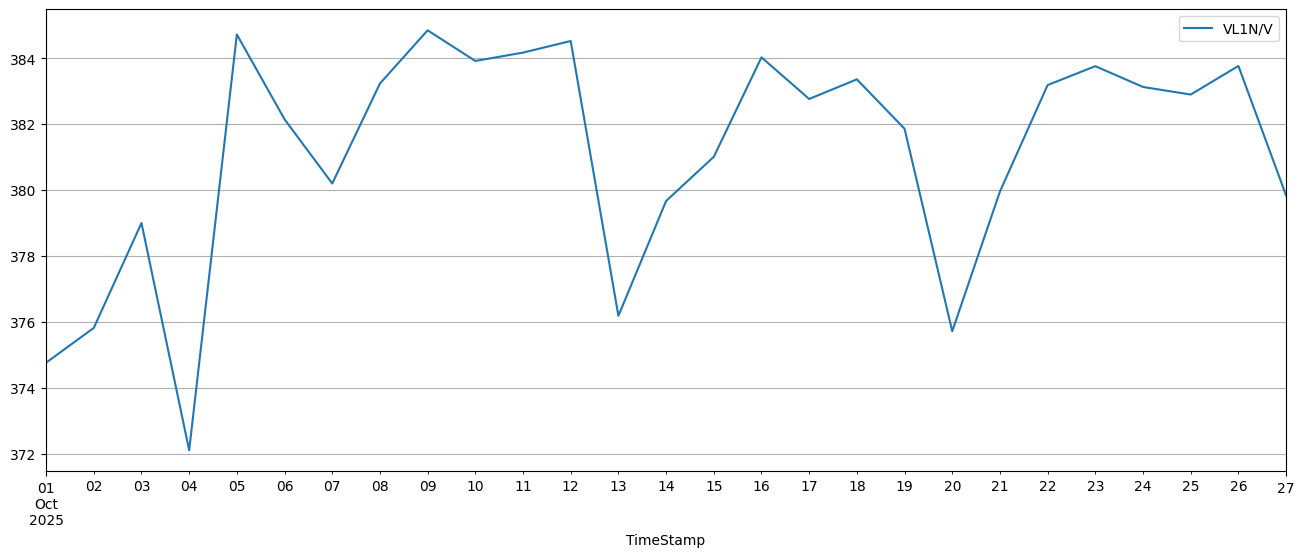

In [9]:
apu3 = stats_apu3.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
apu3['TimeStamp'] = pd.to_datetime(apu3['TimeStamp'])
apu3.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
apu3[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(350,400)
plt.show()
